In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pandas.plotting import scatter_matrix
from sklearn.preprocessing import PowerTransformer
from sklearn.svm import LinearSVC

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [2]:
# load the data and take a peek
df = pd.read_csv("stroke_data.csv")
df.head(n=10)

,Stroke,NASCET,CALCVol,CALCVolProp,MATXVol,MATXVolProp,LRNCVol,LRNCVolProp,MaxCALCArea,MaxCALCAreaProp,...,WallVol,MaxStenosisByDiameter,age,sex,SmokingHistory,AtrialFibrillation,CoronaryArteryDisease,DiabetesHistory,HypercholesterolemiaHistory,HypertensionHistory
0,N,0,235.252599,0.070443,3156.834690,0.759958,224.871710,0.091085,12.350494,0.365768,...,4192.170353,10.544113,72,1,1,0,0,0,0,1
1,N,0,31.433595,0.016165,3032.860796,0.813306,368.560663,0.133989,7.130660,0.211247,...,3917.039836,18.646197,76,1,1,0,0,1,1,1
2,N,0,113.404823,0.038081,3835.220140,0.782526,321.158928,0.083037,16.286916,0.408811,...,4935.327463,19.735114,72,0,0,0,0,0,0,0
3,Y,0,780.823789,0.213432,3518.876937,0.761089,140.517346,0.032065,63.350869,0.576206,...,4909.503817,20.288317,61,1,1,0,0,1,1,1
4,N,0,84.055774,0.041384,2990.273268,0.749869,293.269922,0.075398,17.583561,0.321507,...,4045.053268,49.297050,65,1,0,0,0,0,0,1
5,N,0,5.644322,0.002825,3359.322777,0.849280,55.768884,0.019836,2.841252,0.077346,...,3960.832237,30.508565,64,1,1,0,1,0,1,1
6,N,0,360.737537,0.073351,4444.045173,0.783996,277.262746,0.060740,21.297476,0.386250,...,5814.551863,36.526057,82,0,1,0,1,0,0,1
7,N,0,433.346380,0.151717,3106.593412,0.752070,36.507276,0.014665,27.488064,0.490122,...,2489.344108,31.828904,83,0,0,1,1,0,0,1
8,N,0,133.497204,0.075189,2422.869764,0.847124,104.887066,0.042078,24.019141,0.422159,...,2985.863642,33.333333,85,0,1,0,1,0,1,1
9,N,0,47.231303,0.024471,4674.982758,0.828424,290.074072,0.055439,13.199123,0.271152,...,5676.155090,29.735504,56,0,1,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Stroke                       126 non-null    str    
 1   NASCET                       126 non-null    int64  
 2   CALCVol                      126 non-null    float64
 3   CALCVolProp                  126 non-null    float64
 4   MATXVol                      126 non-null    float64
 5   MATXVolProp                  126 non-null    float64
 6   LRNCVol                      126 non-null    float64
 7   LRNCVolProp                  126 non-null    float64
 8   MaxCALCArea                  126 non-null    float64
 9   MaxCALCAreaProp              126 non-null    float64
 10  MaxDilationByArea            126 non-null    float64
 11  MaxMATXArea                  126 non-null    float64
 12  MaxMATXAreaProp              126 non-null    float64
 13  MaxLRNCArea                  12

In [4]:
sum(df["Stroke"] == "N") / len(df)

0.49206349206349204

In [5]:
# select 30% to set aside, stratified by stroke
p = 0.3
# Super important to seed your random number generator for reproducibility
rng = np.random.default_rng(42) # yes, this is an over-used random number seed
n_test = int(p * len(df))
is_stroke = df["Stroke"] == "Y"
not_stroke = df["Stroke"] == "N"
n_stroke = int(p * is_stroke.sum())
test_ids = np.hstack([rng.choice(np.where(is_stroke)[0], n_stroke),
                     rng.choice(np.where(~is_stroke)[0], n_test - n_stroke)])
train_ids = np.delete(np.arange(len(df)), test_ids)
test = df.iloc[test_ids]
train = df.iloc[train_ids]

# re-define the is_stroke and not_stroke to relate to the training set
# Also cast to simple list to avoid pandas keyindex weirdness after pipeline
is_stroke = list(train["Stroke"] == "Y")
not_stroke = list(train["Stroke"] == "N")

In [6]:
# A way simpler way
# from sklearn.model_selection import train_test_split
# train, test = train_test_split(df, 0.3, random_state=42)

In [7]:
# Verify the splits
print(pd.DataFrame([train.value_counts("Stroke"), test.value_counts("Stroke")], ["Train", "Test"]))

Stroke   N   Y
Train   46  46
Test    18  19


In [8]:
# explore the training data
train.info()

<class 'pandas.DataFrame'>
Index: 92 entries, 0 to 125
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Stroke                       92 non-null     str    
 1   NASCET                       92 non-null     int64  
 2   CALCVol                      92 non-null     float64
 3   CALCVolProp                  92 non-null     float64
 4   MATXVol                      92 non-null     float64
 5   MATXVolProp                  92 non-null     float64
 6   LRNCVol                      92 non-null     float64
 7   LRNCVolProp                  92 non-null     float64
 8   MaxCALCArea                  92 non-null     float64
 9   MaxCALCAreaProp              92 non-null     float64
 10  MaxDilationByArea            92 non-null     float64
 11  MaxMATXArea                  92 non-null     float64
 12  MaxMATXAreaProp              92 non-null     float64
 13  MaxLRNCArea                  92 non-n

In [9]:
# Group the imaging predictors and risk factors
VC_preds = ["CALCVol", "CALCVolProp", "MATXVol", "MATXVolProp", "LRNCVol", 
    "LRNCVolProp", "MaxCALCArea", "MaxCALCAreaProp", "MaxDilationByArea", 
    "MaxMATXArea", "MaxMATXAreaProp", "MaxLRNCArea", "MaxLRNCAreaProp", 
    "MaxMaxWallThickness", "MaxRemodelingRatio", "MaxStenosisByArea", 
    "MaxWallArea", "WallVol", "MaxStenosisByDiameter"]
risk_preds = ["age", "sex", "SmokingHistory", "AtrialFibrillation", "CoronaryArteryDisease", 
    "DiabetesHistory", "HypercholesterolemiaHistory", "HypertensionHistory"]

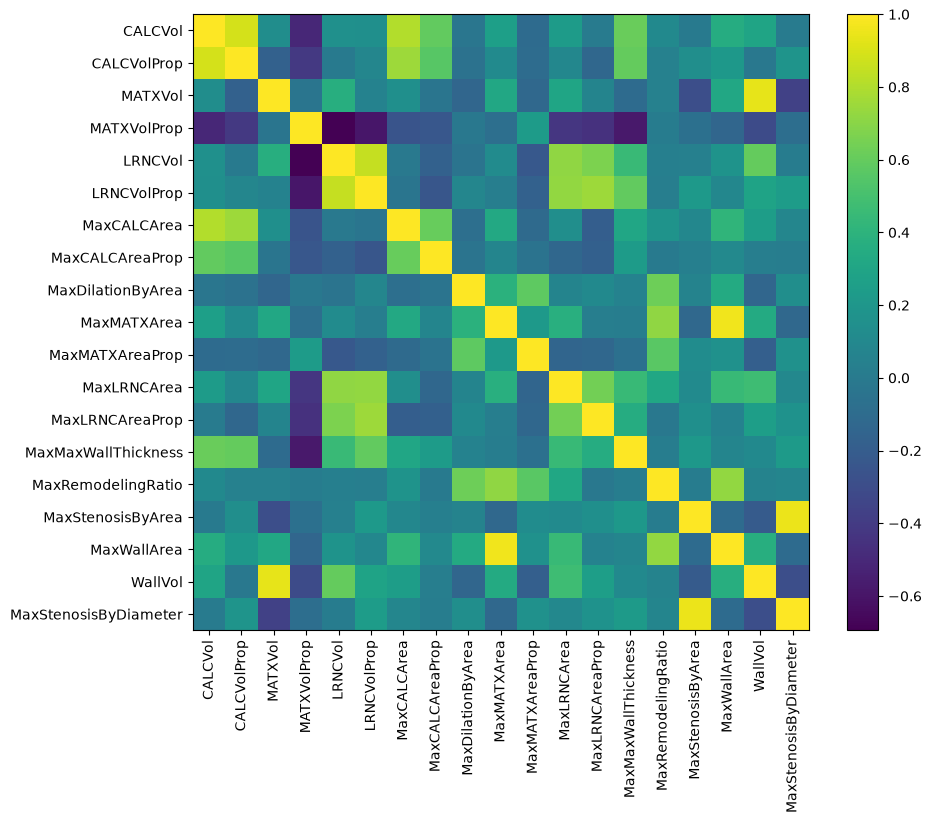

In [10]:
# Look at the correlation coefficients of the imaging predictors
im_corr = train[VC_preds].corr().values
plt.figure(figsize=(10,8))
plt.imshow(im_corr)
plt.colorbar()
plt.xticks(range(len(VC_preds)), VC_preds, rotation=90)
plt.yticks(range(len(VC_preds)), VC_preds)
plt.show()

array([[ 1.        , -0.01936225],
       [-0.01936225,  1.        ]])

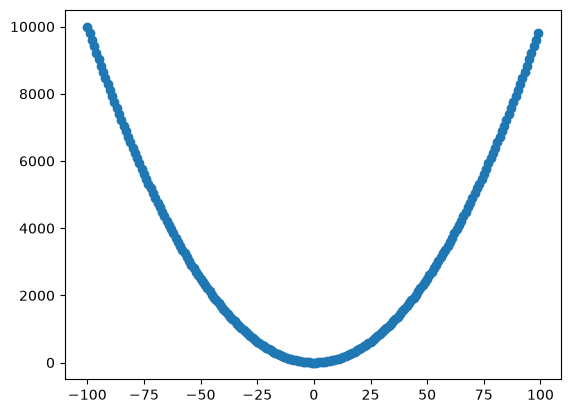

In [11]:
# show that corrcoef only represents linear relationships
test_x = np.arange(-100,100)
test_y = test_x * test_x
plt.scatter(test_x, test_y)
np.corrcoef(test_x, test_y)

In [12]:
# print out features that are off-diagonal but have high correlation
corr_thresh  = 0.9
exclude = []
scatter_check = []
for i in range(len(VC_preds)):
    for j in range(len(VC_preds)):
        if i < j and abs(im_corr[i, j]) > corr_thresh:
            print(f"{VC_preds[i]} is correlated with {VC_preds[j]}")
            exclude.append(VC_preds[i])
            scatter_check += [VC_preds[i], VC_preds[j]]
            
# filter the VC_preds list
preds = [p for p in VC_preds if p not in exclude]

MATXVol is correlated with WallVol
MaxMATXArea is correlated with MaxWallArea
MaxStenosisByArea is correlated with MaxStenosisByDiameter


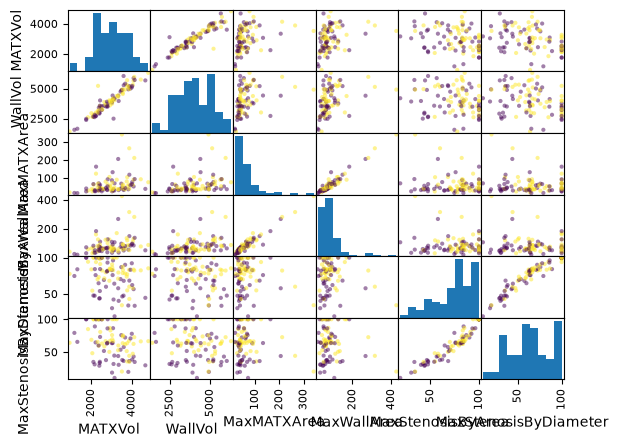

In [13]:
# look at a scatter matrix for the excluded features
scatter_matrix(train[scatter_check], c=is_stroke)#, diagonal='kde')
plt.show()

Text(0.5, 1.0, 'Maximum cross-sectional area of lipid-rich necrotic core')

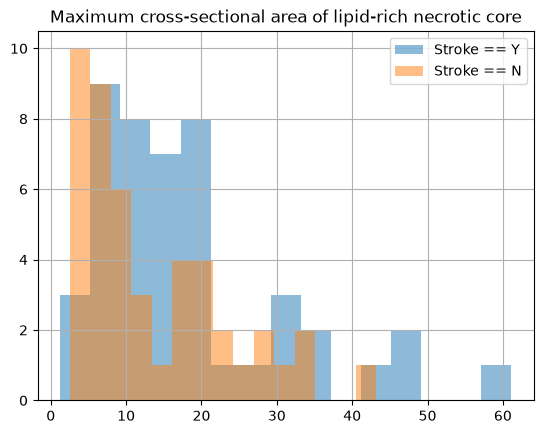

In [14]:
# look at the MaxLRNCArea
train[is_stroke]["MaxLRNCArea"].hist(bins=15, alpha=0.5)
train[not_stroke]["MaxLRNCArea"].hist(bins=15, alpha=0.5)
plt.legend(["Stroke == Y", "Stroke == N"])
plt.title("Maximum cross-sectional area of lipid-rich necrotic core")

Text(0.5, 1.0, 'Log of maximum cross-sectional area of lipid-rich necrotic core')

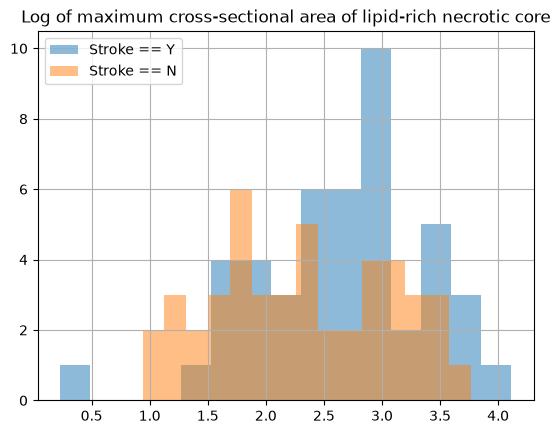

In [15]:
# transfrom MaxLRNCArea and re-do the histogram
t = train["MaxLRNCArea"].apply(lambda x: np.log(x))
t[is_stroke].hist(bins=15, alpha=0.5)
t[not_stroke].hist(bins=15, alpha=0.5)
plt.legend(["Stroke == Y", "Stroke == N"])
plt.title("Log of maximum cross-sectional area of lipid-rich necrotic core")

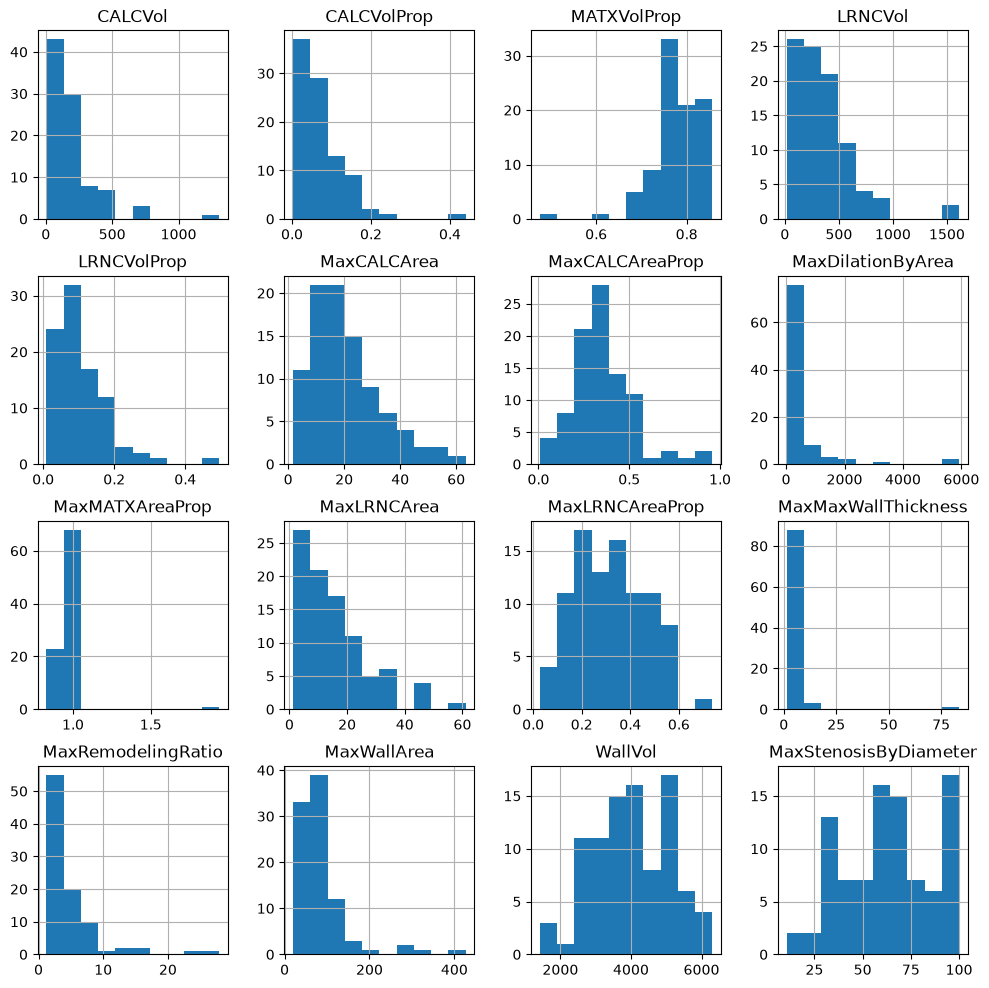

In [16]:
# look at the histograms of all the predictors
train[preds].hist(figsize=(12,12))
plt.show()

In [17]:
# Normalize, then look at the histogram again
transformer = PowerTransformer().set_output(transform="pandas")

# always fit to the training data!
train_scaled = transformer.fit_transform(train[preds])

array([[<Axes: title={'center': 'CALCVol'}>,
        <Axes: title={'center': 'CALCVolProp'}>,
        <Axes: title={'center': 'MATXVolProp'}>,
        <Axes: title={'center': 'LRNCVol'}>],
       [<Axes: title={'center': 'LRNCVolProp'}>,
        <Axes: title={'center': 'MaxCALCArea'}>,
        <Axes: title={'center': 'MaxCALCAreaProp'}>,
        <Axes: title={'center': 'MaxDilationByArea'}>],
       [<Axes: title={'center': 'MaxMATXAreaProp'}>,
        <Axes: title={'center': 'MaxLRNCArea'}>,
        <Axes: title={'center': 'MaxLRNCAreaProp'}>,
        <Axes: title={'center': 'MaxMaxWallThickness'}>],
       [<Axes: title={'center': 'MaxRemodelingRatio'}>,
        <Axes: title={'center': 'MaxWallArea'}>,
        <Axes: title={'center': 'WallVol'}>,
        <Axes: title={'center': 'MaxStenosisByDiameter'}>]], dtype=object)

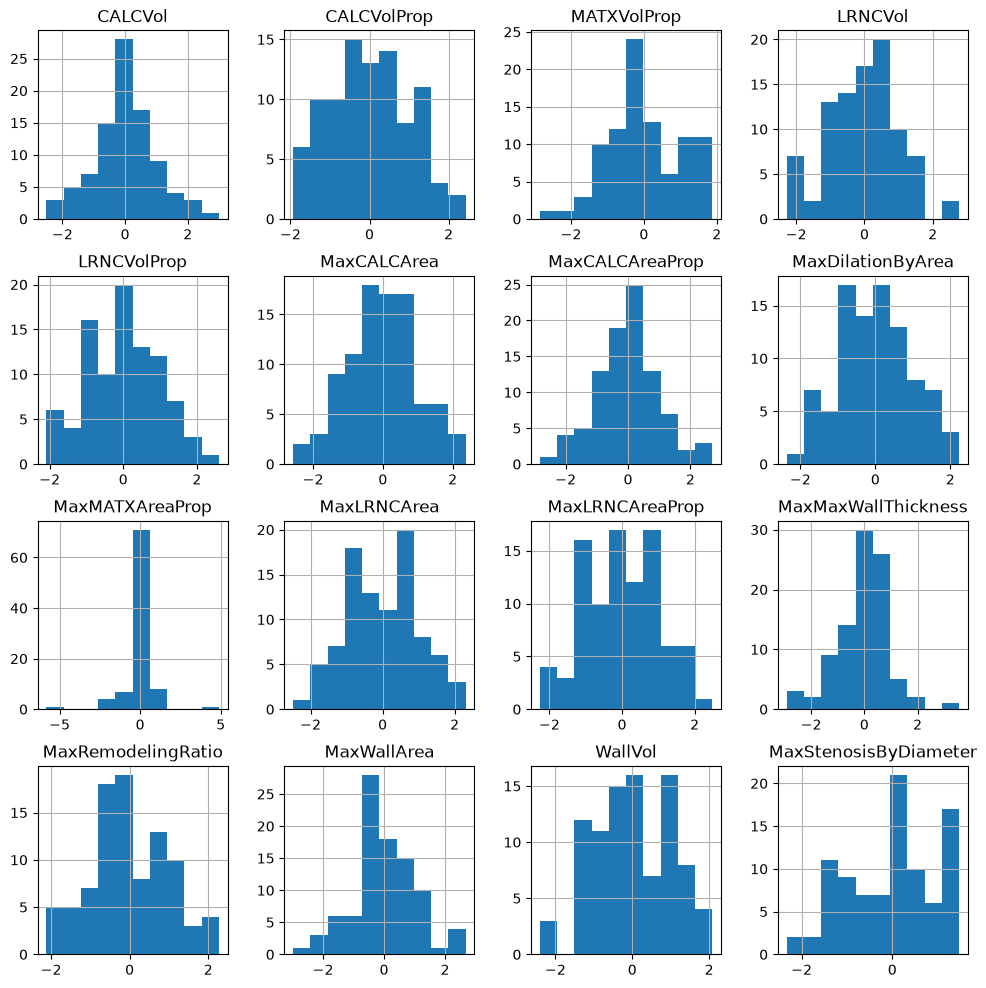

In [18]:
train_scaled.hist(figsize=(12,12))

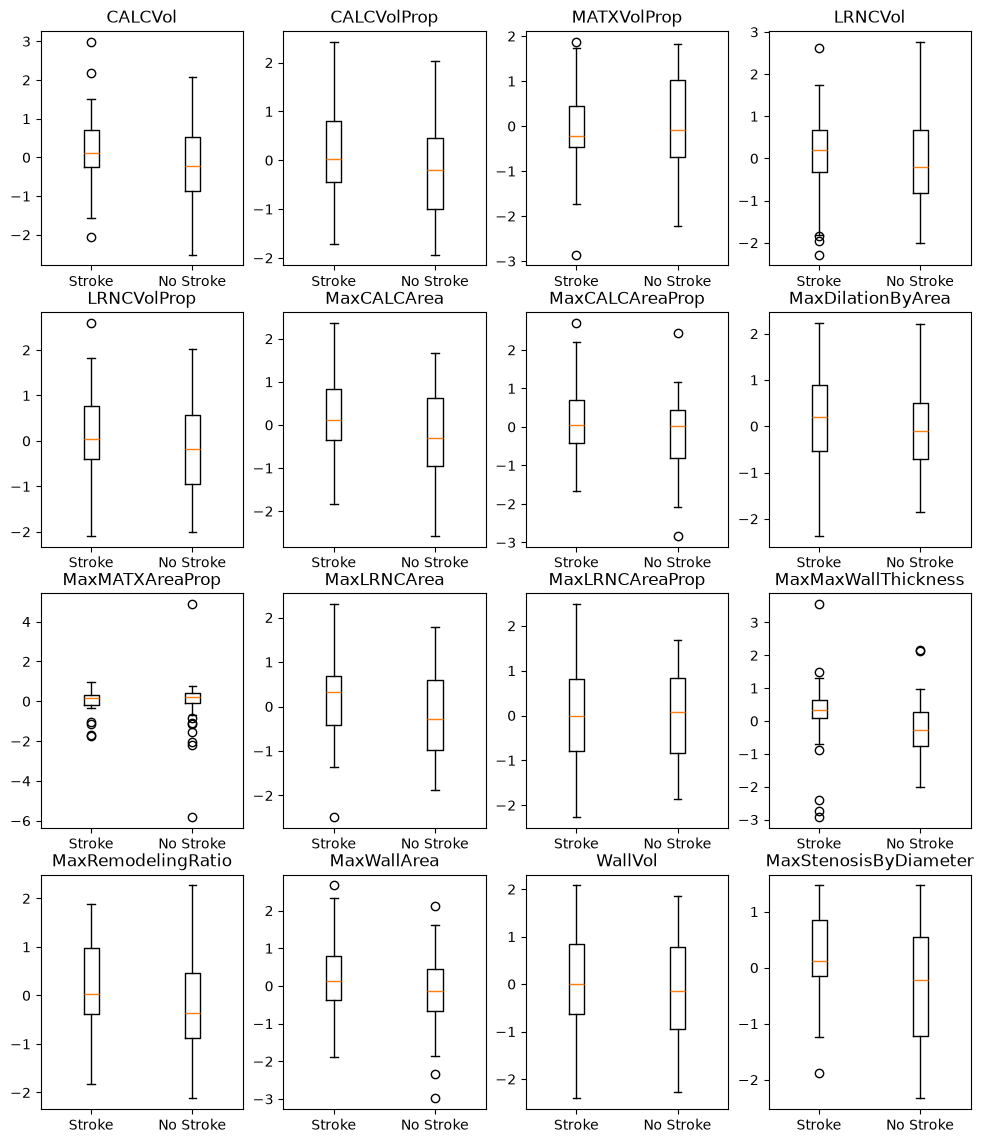

In [19]:
# Any obvious relationships to stroke status?
N = int(np.ceil(len(preds) ** 0.5))
fig,ax = plt.subplots(N,N,figsize=(12,14))
for p, pred in enumerate(preds):
    # figure out the row/col
    row = p // N
    col = p % N
    ax[row][col].boxplot([train_scaled[pred][is_stroke], train_scaled[pred][not_stroke]], tick_labels=["Stroke", "No Stroke"])
    ax[row][col].set_title(pred)

In [20]:
# Let's try a support vector machine
classifier = LinearSVC()
classifier.fit(X=train_scaled, y=is_stroke)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

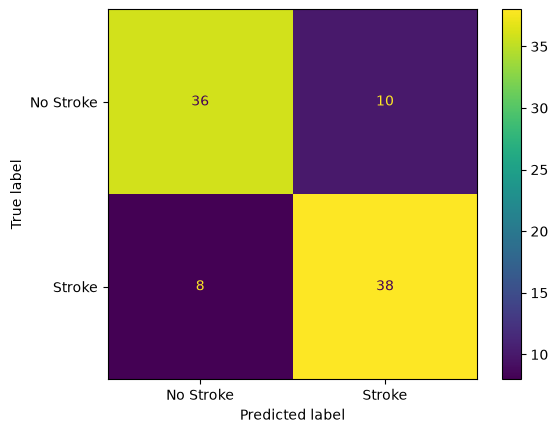

In [21]:
# See how well it worked on the training data
train_pred = classifier.predict(train_scaled)
cm = confusion_matrix(is_stroke, train_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Stroke", "Stroke"])
disp.plot()

In [ ]:
from sklearn.model_selection import cross_val_score
# split the data into k=5 chunks, then train 5 models
# model 1 uses chunks 1-4 to train, tests on chunk 5
# model 2 uses chunks 1-3 + 5 to train, tests on chunk 4 etc
cross_val_score(classifier, train_scaled, is_stroke, scoring="accuracy")
# still data leakage because scaling done on all of training data 
# (we'll talk about more in numeric transformations)

array([0.57894737, 0.68421053, 0.66666667, 0.77777778, 0.72222222])

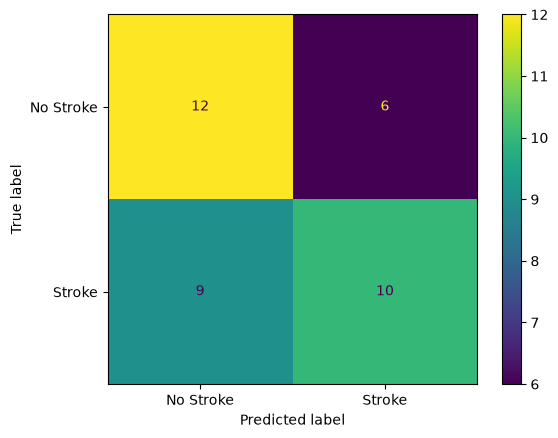

In [22]:
# How does it do on our held-back test set?
# BAD BAD BAD
# Note: skipped a bunch of steps, we shouldn't be looking at test yet!
test_pred = classifier.predict(transformer.transform(test[preds]))
cm = confusion_matrix(test["Stroke"] == "Y", test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Stroke", "Stroke"])
disp.plot()